## Mediapipe Hand Gesture Recognizer Model

The goal of this notebook is to try the hand geture recognizer model from mediapipe, in this case trained in the dataset of rock, papaer, scissors and see if it works in the howdy pipeline
https://ai.google.dev/edge/mediapipe/solutions/customization/gesture_recognizer

## Imports

In [2]:
%matplotlib inline
import os
import tensorflow as tf
assert tf.__version__.startswith('2')

from mediapipe_model_maker import gesture_recognizer

import matplotlib.pyplot as plt

## Import dataset

In [3]:
!wget https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/rps_data_sample.zip
!unzip rps_data_sample.zip
dataset_path = "rps_data_sample"

--2026-03-09 19:31:10--  https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/rps_data_sample.zip
Cargado certificado CA '/etc/ssl/certs/ca-certificates.crt'
Resolviendo storage.googleapis.com (storage.googleapis.com)... 172.217.168.187, 142.251.142.155, 172.217.20.251, ...
Conectando con storage.googleapis.com (storage.googleapis.com)[172.217.168.187]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 12332447 (12M) [application/zip]
Grabando a: ‘rps_data_sample.zip’

rps_data_sample.zip 100%[===================>]  11,76M  15,1MB/s    en 0,8s    

2026-03-09 19:31:11 (15,1 MB/s) - ‘rps_data_sample.zip’ guardado [12332447/12332447]

Archive:  rps_data_sample.zip
   creating: rps_data_sample/
   creating: rps_data_sample/paper/
   creating: rps_data_sample/rock/
   creating: rps_data_sample/scissors/
   creating: rps_data_sample/none/
  inflating: rps_data_sample/paper/77.jpg  
  inflating: rps_data_sample/paper/837.jpg  
  inflating: rps_data_

## See if labels are imported correclty

In [4]:
print(dataset_path)
labels = []
for i in os.listdir(dataset_path):
  if os.path.isdir(os.path.join(dataset_path, i)):
    labels.append(i)
print(labels)

rps_data_sample
['scissors', 'rock', 'paper', 'none']


## See samples for each label

Label: scissors
Label: rock
Label: paper
Label: none


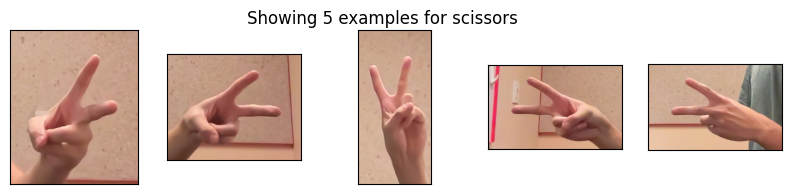

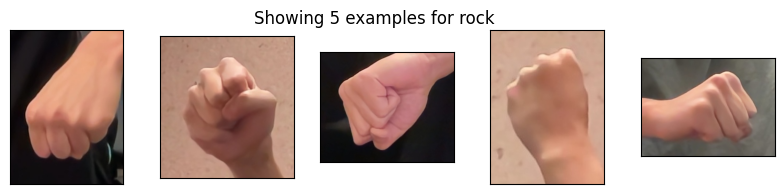

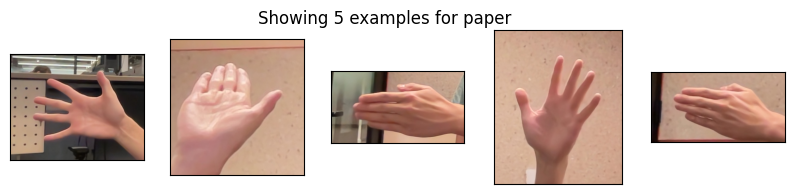

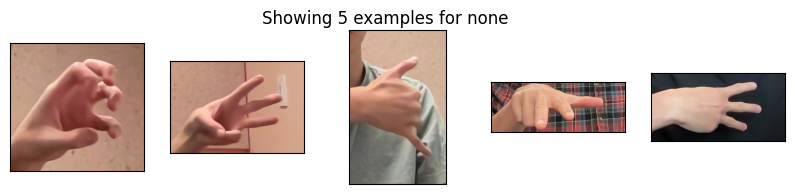

In [5]:
NUM_EXAMPLES = 5

for label in labels:
  print(f'Label: {label}')
  label_dir = os.path.join(dataset_path, label)
  example_filenames = os.listdir(label_dir)[:NUM_EXAMPLES]
  fig, axs = plt.subplots(1, NUM_EXAMPLES, figsize=(10,2))
  for i in range(NUM_EXAMPLES):
    axs[i].imshow(plt.imread(os.path.join(label_dir, example_filenames[i])))
    axs[i].get_xaxis().set_visible(False)
    axs[i].get_yaxis().set_visible(False)
  fig.suptitle(f'Showing {NUM_EXAMPLES} examples for {label}')

plt.show()

## Load datset

In [6]:
data = gesture_recognizer.Dataset.from_folder(
    dirname=dataset_path,
    hparams=gesture_recognizer.HandDataPreprocessingParams()
)
train_data, rest_data = data.split(0.8)
validation_data, test_data = rest_data.split(0.5)

INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/rock/286.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/none/657.jpg


I0000 00:00:1773081075.947283   10228 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773081075.984931   10799 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.3.5-arch1.1), renderer: AMD Radeon Vega 10 Graphics (radeonsi, raven, ACO, DRM 3.61, 6.12.71-1-lts)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773081076.030087   10800 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773081076.058218   10801 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773081076.161878   10807 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/paper/158.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/scissors/57.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/paper/77.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/paper/50.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/paper/855.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/scissors/285.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/rock/431.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/scissors/463.jpg
INFO:tensorflow:Loading image /home/carlos/Escritorio/TFG/tfg/tfg/notebooks/rps_data_sample/scissors/596.jpg
INFO:tensorflow:Loading image /home/ca

INFO:tensorflow:Load valid hands with size: 473, num_label: 4, labels: none,paper,rock,scissors.


## Train model

In [7]:
hparams = gesture_recognizer.HParams(export_dir="rock_exported_model")
options = gesture_recognizer.GestureRecognizerOptions(hparams=hparams)
model = gesture_recognizer.GestureRecognizer.create(
    train_data=train_data,
    validation_data=validation_data,
    options=options
)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hand_embedding (InputLayer  [(None, 128)]             0         
 )                                                               
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 128)               0         
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 custom_gesture_recognizer_  (None, 4)                 516       
 out (Dense)                                                     
                                                             

INFO:tensorflow:Training the models...


Epoch 1/10
189/189 [==============================] - 4s 11ms/step - loss: 1.1270 - categorical_accuracy: 0.2407 - val_loss: 0.7392 - val_categorical_accuracy: 0.5532 - lr: 0.0010
Epoch 2/10
189/189 [==============================] - 2s 9ms/step - loss: 0.7429 - categorical_accuracy: 0.4153 - val_loss: 0.4735 - val_categorical_accuracy: 0.6809 - lr: 9.9000e-04
Epoch 3/10
189/189 [==============================] - 2s 8ms/step - loss: 0.6360 - categorical_accuracy: 0.5212 - val_loss: 0.3750 - val_categorical_accuracy: 0.7021 - lr: 9.8010e-04
Epoch 4/10
189/189 [==============================] - 2s 8ms/step - loss: 0.5906 - categorical_accuracy: 0.5423 - val_loss: 0.3235 - val_categorical_accuracy: 0.7447 - lr: 9.7030e-04
Epoch 5/10
189/189 [==============================] - 2s 10ms/step - loss: 0.5603 - categorical_accuracy: 0.5608 - val_loss: 0.2863 - val_categorical_accuracy: 0.7447 - lr: 9.6060e-04
Epoch 6/10
189/189 [==============================] - 2s 9ms/step - loss: 0.5372 - cate

## Test accuracy

In [8]:
loss, acc = model.evaluate(test_data, batch_size=1)
print(f"Test loss:{loss}, Test accuracy:{acc}")

48/48 [==============================] - 1s 4ms/step - loss: 0.1648 - categorical_accuracy: 0.8542
Test loss:0.16480258107185364, Test accuracy:0.8541666865348816


## Export model

In [9]:
model.export_model()

Using existing files at /tmp/model_maker/gesture_recognizer/palm_detection_full.tflite
Using existing files at /tmp/model_maker/gesture_recognizer/hand_landmark_full.tflite
INFO:tensorflow:Assets written to: /tmp/tmpsbxb_64_/saved_model/assets


INFO:tensorflow:Assets written to: /tmp/tmpsbxb_64_/saved_model/assets
2026-03-09 19:32:37.753155: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-09 19:32:37.753238: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-09 19:32:37.754026: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpsbxb_64_/saved_model
2026-03-09 19:32:37.756291: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-09 19:32:37.756360: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpsbxb_64_/saved_model
2026-03-09 19:32:37.760579: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-03-09 19:32:37.761628: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-03-09 19:32:37.794158: I tensorflow/cc/saved_model/